# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The dataset I chose was the Flight Delay and Causes dataset from Kaggle https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes. The data includes flight level information such as departure/arrival times, origin and destination airports, delays, cancellation information, and delay cause categories (carrier delay, weather delay, National Aviation System delay, security delay, and late aircraft delay).

Who: My target audience would be airline operations managers, aiprort operation teams, or analysts responsible for reducing delays. 

What: Identify which delay types contribute most to total delays, which airports/routes appear most frequently in delayed flights, and wheteher certain times/days are associated with more delays. The goal is to support decisons on scheduling and opertional planning to reduce delays.  

How: I would start with summary charts showing distribution of arrival and departure delays to show the overall delay patterns. I would then try to create some graphs after I analyze the inital data to show any trends. 

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [3]:
#df_flight_dataset = pd.read_csv("flight_data.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
df_flight_dataset = pd.read_csv("flight_delay_cancellation.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
#df_supply_chain_dataset.head()
#I chose to limit some of the columns of data so that I could see it all when I did my code . I limited to columns that would impact delivery
print(df_flight_dataset.describe())
#adjusted the format as it would cause errors for the median, mode, and median calculations. 
#df_delivery = df_flight_dataset[["Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Department Id","Order Item Quantity","Sales","Order Item Total","Product Status","shipping date (DateOrders)"]].copy()
#df_delivery["shipping date (DateOrders)"] = pd.to_datetime(df_delivery["shipping date (DateOrders)"], format='%m/%d/%Y', errors="coerce")
#df_delivery.describe()

         YEAR   MONTH     DAY  DAY_OF_WEEK  FLIGHT_NUMBER  \
count  9999.0  9999.0  9999.0       9999.0    9999.000000   
mean   2015.0     1.0     1.0          4.0    2165.590959   
std       0.0     0.0     0.0          0.0    1846.153120   
min    2015.0     1.0     1.0          4.0       1.000000   
25%    2015.0     1.0     1.0          4.0     698.000000   
50%    2015.0     1.0     1.0          4.0    1566.000000   
75%    2015.0     1.0     1.0          4.0    3263.000000   
max    2015.0     1.0     1.0          4.0    7438.000000   

       SCHEDULED_DEPARTURE  DEPARTURE_TIME  DEPARTURE_DELAY     TAXI_OUT  \
count          9999.000000     9611.000000      9611.000000  9610.000000   
mean           1148.478648     1164.749662         7.347414    14.945578   
std             326.293651      334.149009        30.768328     6.879518   
min               5.000000        2.000000       -22.000000     3.000000   
25%             900.000000      908.500000        -4.000000    11.0000

Here I identify any other inconsistent data. 
Some inconsistent information I found are some of the shipping days scheduled and that are real have 0 day shipments which does not make sense. I also see a big outlier with benefit per order and order profit order with a value of -783, which I imagine should not be a negative value. I also found that there are no product descriptions and all the values in product status is 0. 

In [5]:
df_flight_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 9999 non-null   int64  
 1   MONTH                9999 non-null   int64  
 2   DAY                  9999 non-null   int64  
 3   DAY_OF_WEEK          9999 non-null   int64  
 4   AIRLINE              9999 non-null   object 
 5   FLIGHT_NUMBER        9999 non-null   int64  
 6   TAIL_NUMBER          9986 non-null   object 
 7   ORIGIN_AIRPORT       9999 non-null   object 
 8   DESTINATION_AIRPORT  9999 non-null   object 
 9   SCHEDULED_DEPARTURE  9999 non-null   int64  
 10  DEPARTURE_TIME       9611 non-null   float64
 11  DEPARTURE_DELAY      9611 non-null   float64
 12  TAXI_OUT             9610 non-null   float64
 13  WHEELS_OFF           9610 non-null   float64
 14  SCHEDULED_TIME       9999 non-null   int64  
 15  ELAPSED_TIME         9592 non-null   f

In [6]:
#Identify if there are any duplicates 
#duplicate_rows = df_delivery.duplicated().sum()
#print(duplicate_rows)
#there are no duplicates within this dataset. 
df_flight_dataset.duplicated().sum()
#checked the rest of the column as well but no duplicates 

np.int64(0)

In [7]:
#Here I get the mean, median, and mode
df_flight = df_flight_dataset.drop(columns = ["FLIGHT_NUMBER", "AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"]).copy()
df_mean = df_flight.mean()
df_mean

YEAR                   2015.000000
MONTH                     1.000000
DAY                       1.000000
DAY_OF_WEEK               4.000000
SCHEDULED_DEPARTURE    1148.478648
DEPARTURE_TIME         1164.749662
DEPARTURE_DELAY           7.347414
TAXI_OUT                 14.945578
WHEELS_OFF             1190.269199
SCHEDULED_TIME          145.963096
ELAPSED_TIME            142.725292
AIR_TIME                120.362073
DISTANCE                855.952295
WHEELS_ON              1390.454602
TAXI_IN                   7.422949
SCHEDULED_ARRIVAL      1391.625463
ARRIVAL_TIME           1402.213244
ARRIVAL_DELAY             2.430671
DIVERTED                  0.001500
CANCELLED                 0.039204
AIR_SYSTEM_DELAY          9.099595
SECURITY_DELAY            0.140127
AIRLINE_DELAY            21.027794
LATE_AIRCRAFT_DELAY      15.434858
WEATHER_DELAY             1.678633
dtype: float64

In [8]:
df_median = df_flight.median()
df_median

YEAR                   2015.0
MONTH                     1.0
DAY                       1.0
DAY_OF_WEEK               4.0
SCHEDULED_DEPARTURE    1149.0
DEPARTURE_TIME         1200.0
DEPARTURE_DELAY          -1.0
TAXI_OUT                 13.0
WHEELS_OFF             1215.0
SCHEDULED_TIME          130.0
ELAPSED_TIME            128.0
AIR_TIME                105.0
DISTANCE                722.0
WHEELS_ON              1412.0
TAXI_IN                   6.0
SCHEDULED_ARRIVAL      1413.0
ARRIVAL_TIME           1419.0
ARRIVAL_DELAY            -4.0
DIVERTED                  0.0
CANCELLED                 0.0
AIR_SYSTEM_DELAY          3.0
SECURITY_DELAY            0.0
AIRLINE_DELAY             8.0
LATE_AIRCRAFT_DELAY       0.0
WEATHER_DELAY             0.0
dtype: float64

In [9]:
df_mode = df_flight.mode()
df_mode


,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015.0,1.0,1.0,4.0,600.0,1228.0,-3.0,11.0,1421.0,85.0,...,1430,1720.0,-6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1600,1747.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#Find null or na values
print(df_flight_dataset.isna().sum())
#print(df_supply_chain_dataset.isnull().sum())
#Missing values for order zipcode and product description
#converted the na values to 0 to show that they are missing values for the statistic. I did not remove the
#data as that would remove almost all the data. However for product description, it will not mattter with making those values 0 as all values were missing
df_flight_dataset.fillna(0)


YEAR                      0
MONTH                     0
DAY                       0
DAY_OF_WEEK               0
AIRLINE                   0
FLIGHT_NUMBER             0
TAIL_NUMBER              13
ORIGIN_AIRPORT            0
DESTINATION_AIRPORT       0
SCHEDULED_DEPARTURE       0
DEPARTURE_TIME          388
DEPARTURE_DELAY         388
TAXI_OUT                389
WHEELS_OFF              389
SCHEDULED_TIME            0
ELAPSED_TIME            407
AIR_TIME                407
DISTANCE                  0
WHEELS_ON               395
TAXI_IN                 395
SCHEDULED_ARRIVAL         0
ARRIVAL_TIME            395
ARRIVAL_DELAY           407
DIVERTED                  0
CANCELLED                 0
CANCELLATION_REASON    9607
AIR_SYSTEM_DELAY       8272
SECURITY_DELAY         8272
AIRLINE_DELAY          8272
LATE_AIRCRAFT_DELAY    8272
WEATHER_DELAY          8272
dtype: int64


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,0,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,0,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,0,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,2015,1,1,4,MQ,2811,N636MQ,ORD,BUF,1705,...,1928.0,-5.0,0,0,0,0.0,0.0,0.0,0.0,0.0
9995,2015,1,1,4,HA,165,N492HA,OGG,HNL,1705,...,1757.0,17.0,0,0,0,0.0,0.0,7.0,10.0,0.0
9996,2015,1,1,4,MQ,3046,N610MQ,DBQ,ORD,1705,...,1743.0,-32.0,0,0,0,0.0,0.0,0.0,0.0,0.0
9997,2015,1,1,4,MQ,3048,N679MQ,ORD,CMI,1705,...,1814.0,26.0,0,0,0,10.0,0.0,5.0,11.0,0.0


In [11]:
#Using one hot encoding to adjust some of the category of data

#Adjusted the shipping mode to use ints 
unique=df_flight_dataset["AIRLINE"].unique
df_flight_fixed = df_flight_dataset
one_hot = pd.get_dummies(df_flight_dataset["AIRLINE"], dtype=int)
df_flight_fixed = df_flight_dataset.join(one_hot)
df_flight_fixed.iloc[0:5]

#Adjusted the delivery status to use ints 
#df_supply_fixed = df_supply_chain_dataset.drop(columns=df_supply_chain_dataset["Delivery Status"].unique(), errors="ignore")
#one_hot = pd.get_dummies(df_supply_chain_dataset["Delivery Status"], dtype=int)
#df_supply_fixed = df_supply_chain_dataset.join(one_hot)
#df_supply_fixed.iloc[0:5]




,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,0,0,0,0,0,0,0,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,0,0,0,0,0,0,0,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,0,0,0,0,0,1,0,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,0,0,0,0,0,0,0,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,0,0,0,0,0,0,0,0


In [12]:
#Check for categorical imbalances

#asked google how to check the values of a column of  data with panda dataframe using python
tailnum_mode = df_flight_dataset["CANCELLATION_REASON"].value_counts(dropna=False)
print(tailnum_mode)
counts_taxiout = df_flight_dataset["AIR_SYSTEM_DELAY"].value_counts(dropna=False)
print(counts_taxiout)
cancellation_code = df_flight_dataset["ARRIVAL_DELAY"].value_counts(dropna=False)
print(cancellation_code)

CANCELLATION_REASON
NaN    9607
B       293
A        67
C        32
Name: count, dtype: int64
AIR_SYSTEM_DELAY
NaN      8272
0.0       775
16.0       51
4.0        50
18.0       43
         ... 
59.0        1
138.0       1
53.0        1
72.0        1
68.0        1
Name: count, Length: 66, dtype: int64
ARRIVAL_DELAY
 NaN      407
-6.0      301
-9.0      299
-5.0      295
-7.0      283
         ... 
 136.0      1
-53.0       1
 254.0      1
 299.0      1
 316.0      1
Name: count, Length: 238, dtype: int64


Conclusion
- Are the data usable?  If not, find some new data! 
The dataset is usable for exploratory analysis of flight operations and delays. The dataset has numerous rows and columns with a mix of numeric data and string data like ariline and airports. Most columns show non-null values so no major missing data. 

- Do you need to modify or correct the data in some way?
I did not modify or correct the data but the time fileds (DepTime and ArrTime) should be adjusted to represent clock time as they are formated as an int. Based on the checks there was no missing or duplicate values. 

- Is there any class imbalance?  (Categories that have many more items than other categories).
There was some imbalance with the data I collected as I was only able to put 10000 datapoints as python was not able to handle the full dataset. The cancellationCode was almost dominated by one single value in the output showed. The TailNum alsow shoed up many times compared to other aircrafts. 

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

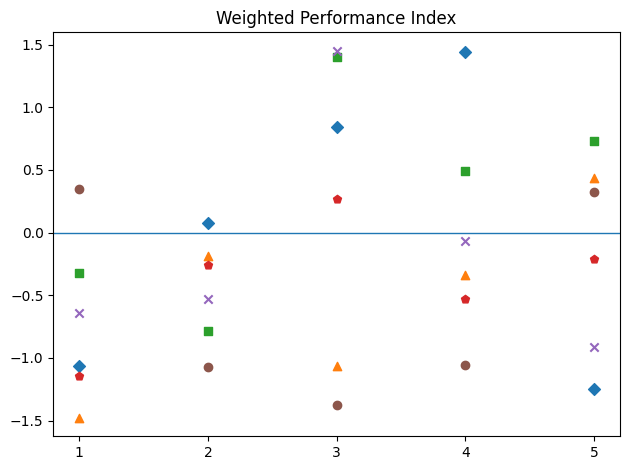

In [13]:
#I will attempt to create teh weighted performance index 

import matplotlib.pyplot as plt

competitors = ["Our Business", "Competitor A", "Competitor B", "Competitor C", "Competitor D", "Competitor E"]
categories = ["1","2","3","4","5"]
x= np.arange(len(categories))
#create arrays for each competitor

data = {
    "Our Business": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor A": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor B": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor C": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor D": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor E": np.random.uniform(-1.50, 1.50, size = 5)
} 

#Due ot this being a dictionary so I will have to separate the x and y values
x_values=[]
y_values=[]


markers = {
    "Our Business": "D",
    "Competitor A": "^",
    "Competitor B": "s",
    "Competitor C": "p",
    "Competitor D": "x",
    "Competitor E": "o"
} 


for comp, y in data.items():
    plt.scatter(x, y, marker = markers[comp], label=comp)


plt.title("Weighted Performance Index")
plt.xticks(x, categories)
plt.axhline(0, linewidth=1)
#plt.legend()

plt.tight_layout()
